![image.png](https://i.imgur.com/a3uAqnb.png)

# Mixture of Experts Routing: Building and Balancing a Sparse Language Model

- **Dataset**: [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) from Hugging Face, 2.1 million short stories in simple English (Eldan and Li, 2023)
- **Task**: next-token language modelling with a sparse mixture-of-experts feed-forward layer, with and without a load-balancing loss
- **Model**: a 6-layer mixture-of-experts Transformer written in this notebook (about 80M parameters, 8 experts per layer, 2 active per token), trained from scratch, then [OLMoE-1B-7B](https://huggingface.co/allenai/OLMoE-1B-7B-0924) as a production example
- **Runtime**: Colab A100 GPU 

In this lab, we will:

- implement a top-k router and a sparse mixture-of-experts layer that replaces the feed-forward block of a Transformer
- implement the Switch Transformer load-balancing loss and the ST-MoE router z-loss
- train the same model twice on real text, with and without the auxiliary losses, and watch the expert load, MaxVio and the loss
- read the same routing statistics off a production open-weights mixture of experts

## What is a mixture-of-experts layer?

In a dense Transformer every token passes through the same feed-forward network. A mixture-of-experts (MoE) layer keeps $N$ feed-forward networks, the experts, and a linear router that sends each token to the $k$ experts with the highest scores. The layer holds the parameters of $N$ experts while each token pays for $k$, and the output is the weighted sum of the selected experts.

$$p_i(x) = \frac{e^{h(x)_i}}{\sum_{j=1}^{N} e^{h(x)_j}}, \qquad y = \sum_{i \in \mathcal{T}} p_i(x)\, E_i(x)$$

Where:
- $x \in \mathbb{R}^d$ is one token's hidden vector and $h(x) = W_r x \in \mathbb{R}^N$ are the router logits
- $p_i(x)$ is the router probability of expert $i$ and $\mathcal{T}$ is the set of the $k$ experts with the largest probabilities
- $E_i(x)$ is the output of expert $i$, a feed-forward network

Nothing stops the router from sending most tokens to a few experts, and an expert that receives more tokens learns faster, so routing tends to collapse. The Switch Transformer adds an auxiliary loss that is smallest when the load is uniform:

$$\mathcal{L}_B = \alpha \cdot N \sum_{i=1}^{N} f_i\, P_i, \qquad f_i = \frac{1}{T}\sum_{x \in \mathcal{B}} \mathbb{1}\{i \in \mathcal{T}(x)\}, \qquad P_i = \frac{1}{T}\sum_{x \in \mathcal{B}} p_i(x)$$

Where $\mathcal{B}$ is a batch of $T$ tokens, $f_i$ is the fraction of tokens routed to expert $i$, $P_i$ is the mean router probability of expert $i$ and $\alpha$ is a small coefficient, $10^{-2}$ in the paper. Only $P_i$ is differentiable, and its gradient pushes probability away from the experts that already receive many tokens.

Paper: [Fedus et al., 2021. Switch Transformers: Scaling to Trillion Parameter Models with Simple and Efficient Sparsity](https://arxiv.org/abs/2101.03961)

## Setup

This lab needs an A100 GPU: in Google Colab, select **Runtime > Change runtime type > A100 GPU** (40 GB or 80 GB), then run the cells from top to bottom. Training needs about 8 GB of GPU memory, and the production model in the last part about 18 GB (14 GB of bfloat16 weights plus activations).

In [1]:
import gc
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.models.mixtral.modeling_mixtral import load_balancing_loss_func

Every size and length knob lives in this cell. Each training run sees at most `MAX_STEPS` batches of `BATCH_SIZE x SEQ_LEN` tokens, about 33M tokens. The two runs differ only in `AUX_COEF` and `Z_COEF`, which the training loop reads from the run table below.

In [2]:
SEED = 42
N_TRAIN = 200_000        # stories to tokenise (the first train shard holds about 530,000)
N_VAL = 2_000            # held-out stories
SEQ_LEN = 512            # tokens per training sequence
BATCH_SIZE = 32          # sequences per step, so 16,384 tokens per step
EPOCHS = 1
MAX_STEPS = 2_000        # cap on optimizer steps per epoch and per run, about 33M tokens
LR = 1e-3
WARMUP_STEPS = 100
WEIGHT_DECAY = 0.1
LOG_EVERY = 50           # steps between recorded training statistics
EVAL_EVERY = 500         # steps between validation losses
NUM_WORKERS = 2          # DataLoader worker processes

HIDDEN_SIZE = 384
N_LAYERS = 6
N_HEADS = 6
N_EXPERTS = 8
TOP_K = 2
EXPERT_SIZE = 1536       # hidden width of one expert, 4 x HIDDEN_SIZE as in the Switch Transformer
AUX_COEF = 1e-2          # load-balancing coefficient alpha (Switch Transformer)
Z_COEF = 1e-3            # router z-loss coefficient (ST-MoE)

OLMOE_ID = "allenai/OLMoE-1B-7B-0924"
N_OLMOE_SEQS = 64        # held-out sequences of SEQ_LEN tokens to route through the production model
OLMOE_BATCH_SIZE = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
    torch.set_float32_matmul_precision("high")
else:
    print("No GPU found, so training will be very slow. In Colab: Runtime > Change runtime type > A100 GPU.")

# Mixed precision: bfloat16 on an A100 or newer (no gradient scaler needed), float16 with a scaler
# on an older GPU, off on the CPU.
USE_AMP = DEVICE == "cuda"
AMP_DTYPE = torch.bfloat16 if USE_AMP and torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)

PyTorch 2.11.0+cu130 | device: cuda
GPU: NVIDIA A100-SXM4-40GB (42.4 GB)


## 1. Dataset

- **Source**: [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) on Hugging Face (Eldan and Li, 2023)
- **Content**: 2,119,719 training stories and 21,990 validation stories, one `text` column, written by GPT-3.5 and GPT-4 with the vocabulary of a young child
- **Licence**: CDLA-Sharing-1.0
- **What we use**: the first of the four training parquet shards (about 250 MB) and the validation shard, from which we take `N_TRAIN` training and `N_VAL` validation stories

We tokenise with the GPT-2 byte-pair tokenizer (50,257 tokens) and pack the stories into fixed-length sequences, the standard preparation for training a causal language model from scratch.

In [3]:
dataset = load_dataset(
    "roneneldan/TinyStories",
    data_files={"train": "data/train-00000-of-00004-*.parquet",
                "validation": "data/validation-*.parquet"},
)
train_split = dataset["train"].shuffle(seed=SEED).select(range(N_TRAIN))
val_split = dataset["validation"].shuffle(seed=SEED).select(range(N_VAL))

tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
EOS_ID = tokenizer.eos_token_id
print(dataset)
print(train_split[0]["text"][:400])

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 529930
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})
Once upon a time, there was a young girl who wanted to go for a round. She wore her shoes and went outside. She jumped and skipped around the little park, twirling and spinning around. She looked so young and happy.

The girl explored the park. She climbed on the monkey bars and slid down the slide. Then she went to the sandbox and dug her way around, finding hidden little treasures in the sand.




We append an end-of-text token to every story, concatenate the stories into one token stream and cut it into `SEQ_LEN` pieces, so no padding is wasted. The targets are the inputs shifted by one position, which the model's loss computes.

In [4]:
def pack_tokens(split, chunk=5_000):
    """Tokenise a split in chunks and pack it into rows of SEQ_LEN tokens. Returns a LongTensor (n_seq, SEQ_LEN)."""
    pieces = []
    for start in tqdm(range(0, len(split), chunk), desc="tokenising", leave=False):
        for ids in tokenizer(split[start:start + chunk]["text"])["input_ids"]:
            pieces.append(np.asarray(ids + [EOS_ID], dtype=np.int32))
    stream = np.concatenate(pieces)                       # (n_tokens,)
    n_seq = len(stream) // SEQ_LEN
    return torch.from_numpy(stream[: n_seq * SEQ_LEN].astype(np.int64)).view(n_seq, SEQ_LEN)


class PackedDataset(Dataset):
    """Rows of SEQ_LEN token ids."""

    def __init__(self, ids):
        self.ids = ids

    def __len__(self):
        return self.ids.size(0)

    def __getitem__(self, i):
        return self.ids[i]


train_ids = pack_tokens(train_split)
val_ids = pack_tokens(val_split)
train_loader = DataLoader(PackedDataset(train_ids), batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                          num_workers=NUM_WORKERS, pin_memory=DEVICE == "cuda")
val_loader = DataLoader(PackedDataset(val_ids), batch_size=BATCH_SIZE,
                        num_workers=NUM_WORKERS, pin_memory=DEVICE == "cuda")

batch = next(iter(train_loader))
print(f"train sequences: {train_ids.shape}, validation sequences: {val_ids.shape}")
print(f"one batch: {tuple(batch.shape)}   # (BATCH_SIZE, SEQ_LEN)")

tokenising:   0%|          | 0/40 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1047 > 1024). Running this sequence through the model will result in indexing errors


tokenising:   0%|          | 0/1 [00:00<?, ?it/s]

train sequences: torch.Size([87753, 512]), validation sequences: torch.Size([856, 512])
one batch: (32, 512)   # (BATCH_SIZE, SEQ_LEN)


## 2. Model

### The router and the experts

The router is one linear map from the hidden size to `N_EXPERTS` logits, computed in float32 as production models do, because the router softmax is where rounding errors hurt most. We keep the `TOP_K` largest probabilities, renormalise them to sum to one (the Mixtral convention) and also return the raw logits, which the auxiliary losses need.

Each expert is a two-layer feed-forward network. The layer gathers the tokens assigned to each expert, runs the expert once on them, scales the outputs by the routing weights and adds them back in place. No expert has a capacity limit, so no token is dropped: this is the dropless routing of current models, where the auxiliary loss alone keeps the load even.

In [5]:
class TopKRouter(nn.Module):
    """Linear router: scores every token, keeps the top-k experts and renormalises their probabilities."""

    def __init__(self, hidden_size, n_experts, top_k):
        super().__init__()
        self.top_k = top_k
        self.weight = nn.Linear(hidden_size, n_experts, bias=False)

    def forward(self, tokens):
        logits = self.weight(tokens).float()                           # (n_tokens, N_EXPERTS), float32 for the softmax
        probs = logits.softmax(dim=-1)                                 # p_i(x)
        top_p, top_i = probs.topk(self.top_k, dim=-1)                  # (n_tokens, TOP_K) each
        weights = top_p / top_p.sum(dim=-1, keepdim=True)              # renormalised over the selected experts
        return logits, weights.to(tokens.dtype), top_i


class Expert(nn.Module):
    """One feed-forward network: hidden -> EXPERT_SIZE -> hidden."""

    def __init__(self, hidden_size, expert_size):
        super().__init__()
        self.up = nn.Linear(hidden_size, expert_size)
        self.down = nn.Linear(expert_size, hidden_size)

    def forward(self, x):
        return self.down(F.gelu(self.up(x)))


class MoELayer(nn.Module):
    """Sparse mixture of experts: each token is processed by its top-k experts, weighted by the router."""

    def __init__(self, hidden_size, expert_size, n_experts, top_k):
        super().__init__()
        self.router = TopKRouter(hidden_size, n_experts, top_k)
        self.experts = nn.ModuleList(Expert(hidden_size, expert_size) for _ in range(n_experts))

    def forward(self, x):
        B, T, D = x.shape
        tokens = x.reshape(-1, D)                                      # (B*T, D): routing is per token
        logits, weights, top_i = self.router(tokens)
        out = torch.zeros_like(tokens)
        assignment = F.one_hot(top_i, len(self.experts)).permute(2, 1, 0)   # (N_EXPERTS, TOP_K, B*T)
        for e, expert in enumerate(self.experts):
            slot, idx = torch.where(assignment[e])                     # the tokens that chose expert e, and in which slot
            if idx.numel() == 0:
                continue                                                # a starved expert: no tokens this batch
            out.index_add_(0, idx, weights[idx, slot, None] * expert(tokens[idx]))
        return out.view(B, T, D), logits


moe = MoELayer(HIDDEN_SIZE, EXPERT_SIZE, N_EXPERTS, TOP_K)
y, router_logits = moe(torch.randn(2, 5, HIDDEN_SIZE))
print(f"output {tuple(y.shape)}, router logits {tuple(router_logits.shape)}   # (B, T, D), (B*T, N_EXPERTS)")

output (2, 5, 384), router logits (10, 8)   # (B, T, D), (B*T, N_EXPERTS)


### The auxiliary losses and the load statistics

`load_balancing_loss` is the Switch Transformer loss of the primer, averaged over layers. It equals `TOP_K` at a perfectly uniform load and grows as the load concentrates. `router_z_loss` is the ST-MoE penalty on the size of the router logits,

$$\mathcal{L}_Z = \frac{1}{T}\sum_{x \in \mathcal{B}} \Big(\log \sum_{j=1}^{N} e^{h(x)_j}\Big)^2,$$

which keeps the logits small so that the softmax stays well conditioned in low precision. We also compute each expert's share of the routed tokens, $\mathrm{Load}_i$, and the maximum violation of Wang et al. (2024),

$$\mathrm{MaxVio} = \frac{\max_i \mathrm{Load}_i - \overline{\mathrm{Load}}}{\overline{\mathrm{Load}}},$$

which is zero at a uniform load and $N - 1$ when one expert takes every token. We check our balancing loss against the `transformers` implementation used by Mixtral and OLMoE.

In [6]:
def expert_load(logits, top_k):
    """Share of the routed tokens each expert receives, (N_EXPERTS,), summing to one."""
    top_i = logits.topk(top_k, dim=-1).indices                         # (n_tokens, TOP_K)
    counts = torch.bincount(top_i.flatten(), minlength=logits.size(-1)).float()
    return counts / counts.sum()


def max_violation(load):
    """(max load - mean load) / mean load: 0 at perfect balance, N - 1 at full collapse."""
    return ((load.max() - load.mean()) / load.mean()).item()


def load_balancing_loss(all_logits, top_k):
    """Switch Transformer loss N * sum_i f_i P_i, averaged over layers (equals top_k at a uniform load)."""
    total = 0.0
    for logits in all_logits:                                          # one (n_tokens, N_EXPERTS) tensor per layer
        n_experts = logits.size(-1)
        probs = logits.softmax(dim=-1)
        top_i = probs.topk(top_k, dim=-1).indices
        f = F.one_hot(top_i, n_experts).sum(dim=1).float().mean(dim=0)   # (N,) fraction of tokens routed to each expert
        P = probs.mean(dim=0)                                              # (N,) mean router probability
        total = total + n_experts * (f * P).sum()
    return total / len(all_logits)


def router_z_loss(all_logits):
    """ST-MoE z-loss: mean squared log-partition of the router logits, averaged over layers."""
    return sum((torch.logsumexp(logits, dim=-1) ** 2).mean() for logits in all_logits) / len(all_logits)


uniform = torch.zeros(1000, N_EXPERTS) + 0.01 * torch.randn(1000, N_EXPERTS)   # nearly uniform routing
collapsed = torch.zeros(1000, N_EXPERTS)
collapsed[:, 0] = 8.0                                                           # every token prefers expert 0
for name, logits in [("uniform", uniform), ("collapsed", collapsed)]:
    load = expert_load(logits, TOP_K)
    print(f"{name:10s}: balancing loss {load_balancing_loss([logits], TOP_K):.3f} "
          f"(transformers: {load_balancing_loss_func((logits,), N_EXPERTS, TOP_K):.3f}), "
          f"z-loss {router_z_loss([logits]):.3f}, MaxVio {max_violation(load):.2f}")

uniform   : balancing loss 2.000 (transformers: 2.000), z-loss 4.324, MaxVio 0.06
collapsed : balancing loss 7.984 (transformers: 7.984), z-loss 64.038, MaxVio 3.00


### A compact mixture-of-experts Transformer

The model is a GPT-style decoder: token and position embeddings, `N_LAYERS` pre-norm blocks with causal multi-head attention through PyTorch's scaled-dot-product kernel, and the `MoELayer` in place of every feed-forward block. The forward pass returns the logits and the router logits of every layer, and the loss cell adds the auxiliary terms to the cross-entropy. The output embedding is tied to the input embedding.

In [7]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention with PyTorch's fused scaled-dot-product kernel."""

    def __init__(self, hidden_size, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.qkv = nn.Linear(hidden_size, 3 * hidden_size, bias=False)
        self.out = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(x).view(B, T, 3, self.n_heads, D // self.n_heads).unbind(dim=2)   # (B, T, H, d) each
        q, k, v = (t.transpose(1, 2) for t in (q, k, v))                                     # (B, H, T, d)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)                          # (B, H, T, d)
        return self.out(y.transpose(1, 2).reshape(B, T, D))


class MoEBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.RMSNorm(HIDDEN_SIZE)
        self.attn = CausalSelfAttention(HIDDEN_SIZE, N_HEADS)
        self.norm2 = nn.RMSNorm(HIDDEN_SIZE)
        self.moe = MoELayer(HIDDEN_SIZE, EXPERT_SIZE, N_EXPERTS, TOP_K)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        h, router_logits = self.moe(self.norm2(x))
        return x + h, router_logits


class MoELM(nn.Module):
    """A decoder-only language model whose feed-forward blocks are sparse mixtures of experts."""

    def __init__(self, vocab_size):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, HIDDEN_SIZE)
        self.pos_emb = nn.Embedding(SEQ_LEN, HIDDEN_SIZE)
        self.blocks = nn.ModuleList(MoEBlock() for _ in range(N_LAYERS))
        self.norm = nn.RMSNorm(HIDDEN_SIZE)
        self.lm_head = nn.Linear(HIDDEN_SIZE, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight                      # tied embeddings
        self.apply(self._init)

    @staticmethod
    def _init(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, std=0.02)
            if getattr(module, "bias", None) is not None:
                nn.init.zeros_(module.bias)

    def forward(self, ids):
        B, T = ids.shape
        x = self.tok_emb(ids) + self.pos_emb(torch.arange(T, device=ids.device))   # (B, T, D)
        all_router_logits = []
        for block in self.blocks:
            x, router_logits = block(x)
            all_router_logits.append(router_logits)                                 # N_LAYERS x (B*T, N_EXPERTS)
        return self.lm_head(self.norm(x)), all_router_logits                        # (B, T, vocab)


def lm_loss(logits, ids):
    """Next-token cross-entropy: position t predicts token t + 1."""
    return F.cross_entropy(logits[:, :-1].reshape(-1, logits.size(-1)).float(), ids[:, 1:].reshape(-1))

We count the total parameters and the parameters active for one token: every expert is stored, but only `TOP_K` of `N_EXPERTS` run per token and layer. The untrained model gives the baseline loss, near $\ln(50{,}257) \approx 10.8$ nats, and its routing is already uneven because the router is random.

In [8]:
def build_model():
    torch.manual_seed(SEED)                                            # identical initial weights for every run
    return MoELM(len(tokenizer)).to(DEVICE)


model = build_model()
n_total = sum(p.numel() for p in model.parameters())
n_expert = sum(p.numel() for block in model.blocks for p in block.moe.experts.parameters())
n_active = n_total - n_expert * (1 - TOP_K / N_EXPERTS)
print(f"total parameters {n_total / 1e6:.1f}M, of which {n_expert / 1e6:.1f}M in experts | "
      f"active per token {n_active / 1e6:.1f}M")


@torch.no_grad()
def evaluate(model, loader, max_batches=None):
    """Mean cross-entropy on a held-out loader and the per-layer expert load, (N_LAYERS, N_EXPERTS)."""
    model.eval()
    total, n = 0.0, 0
    load = torch.zeros(N_LAYERS, N_EXPERTS)
    for i, ids in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        ids = ids.to(DEVICE)
        with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits, router_logits = model(ids)
        total += lm_loss(logits, ids).item()
        load += torch.stack([expert_load(l, TOP_K) for l in router_logits]).cpu()
        n += 1
    model.train()
    return total / max(n, 1), load / max(n, 1)


baseline_loss, baseline_load = evaluate(model, val_loader, max_batches=10)
print(f"untrained: validation loss {baseline_loss:.3f} nats, "
      f"MaxVio per layer {[round(max_violation(l), 2) for l in baseline_load]}")

total parameters 79.8M, of which 56.7M in experts | active per token 37.2M
untrained: validation loss 10.908 nats, MaxVio per layer [0.91, 1.07, 0.91, 1.59, 1.16, 0.88]


## 3. Training

The total loss is $\mathcal{L} = \mathcal{L}_{CE} + \alpha\, \mathcal{L}_B + c_z\, \mathcal{L}_Z$, minimised with AdamW, a linear warm-up, a cosine decay to one tenth of `LR` and gradients clipped to norm 1. The same function trains both runs: the first with `AUX_COEF` and `Z_COEF` from the config cell, the second with both set to zero. Every `LOG_EVERY` steps we record the cross-entropy, the balancing loss and the mean MaxVio over layers of the current batch.

Expected time: about 4 to 5 minutes per run on an A100, about 9 minutes for this section.

In [ ]:
def make_optimizer(model, total_steps):
    """AdamW with linear warm-up and cosine decay to 0.1 x LR."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95))

    def lr_lambda(step):
        if step < WARMUP_STEPS:
            return (step + 1) / WARMUP_STEPS
        progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))

    return optimizer, torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, optimizer, scheduler, history, step, aux_coef, z_coef):
    """One pass over the loader, capped at MAX_STEPS batches. Returns the mean cross-entropy and the global step."""
    model.train()
    total, n = 0.0, 0
    progress = tqdm(iter(loader), total=min(len(loader), MAX_STEPS), desc="train", leave=False)
    for ids in progress:
        if n >= MAX_STEPS:
            break
        ids = ids.to(DEVICE, non_blocking=True)                        # (BATCH_SIZE, SEQ_LEN)
        with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits, router_logits = model(ids)
        ce = lm_loss(logits, ids)
        balance = load_balancing_loss(router_logits, TOP_K)
        z = router_z_loss(router_logits)
        loss = ce + aux_coef * balance + z_coef * z                     # the auxiliary terms are off when the coefficients are 0
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()                                   
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        step += 1
        total += ce.item()
        n += 1
        if step % LOG_EVERY == 0:
            with torch.no_grad():
                maxvio = np.mean([max_violation(expert_load(l, TOP_K)) for l in router_logits])
            history["step"].append(step)
            history["train_loss"].append(ce.item())
            history["balance_loss"].append(balance.item())
            history["maxvio"].append(maxvio)
        if step % EVAL_EVERY == 0:
            history["val_step"].append(step)
            history["val_loss"].append(evaluate(model, val_loader, max_batches=20)[0])
        progress.set_postfix(ce=f"{ce.item():.3f}", balance=f"{balance.item():.3f}")
    return total / max(n, 1), step

In [10]:
runs = {"with balancing loss": (AUX_COEF, Z_COEF), "without balancing loss": (0.0, 0.0)}
steps_per_epoch = min(len(train_loader), MAX_STEPS)
print(f"{steps_per_epoch:,} optimizer steps per epoch, {EPOCHS} epoch(s), "
      f"{steps_per_epoch * EPOCHS * BATCH_SIZE * SEQ_LEN / 1e6:.0f}M tokens per run")

models, histories = {}, {}
for run_name, (aux_coef, z_coef) in runs.items():
    model = build_model()
    optimizer, scheduler = make_optimizer(model, steps_per_epoch * EPOCHS)
    history = {"step": [], "train_loss": [], "balance_loss": [], "maxvio": [], "val_step": [], "val_loss": [],
               "epoch_val_loss": [], "epoch_load": []}
    torch.manual_seed(SEED)                                            # same data order for both runs
    start, step = time.time(), 0
    for epoch in range(1, EPOCHS + 1):
        train_loss, step = train_one_epoch(model, train_loader, optimizer, scheduler, history, step, aux_coef, z_coef)
        val_loss, val_load = evaluate(model, val_loader)
        history["epoch_val_loss"].append(val_loss)
        history["epoch_load"].append(val_load)
        print(f"{run_name} | epoch {epoch}/{EPOCHS}: train loss {train_loss:.4f} | val loss {val_loss:.4f}, "
              f"perplexity {math.exp(val_loss):.1f} | mean MaxVio {np.mean([max_violation(l) for l in val_load]):.2f} | "
              f"{time.time() - start:.0f}s elapsed")
    models[run_name], histories[run_name] = model, history
    del optimizer, scheduler

2,000 optimizer steps per epoch, 1 epoch(s), 33M tokens per run


train:   0%|          | 0/2000 [00:00<?, ?it/s]

with balancing loss | epoch 1/1: train loss 2.5960 | val loss 1.9127, perplexity 6.8 | mean MaxVio 0.19 | 299s elapsed


train:   0%|          | 0/2000 [00:00<?, ?it/s]

without balancing loss | epoch 1/1: train loss 2.5926 | val loss 1.9213, perplexity 6.8 | mean MaxVio 2.48 | 295s elapsed


## 4. Results

Three curves against the optimizer step for both runs: the cross-entropy on training batches and on the validation set, the balancing loss (which we only minimise in the first run but measure in both), and the MaxVio of the current batch averaged over layers.

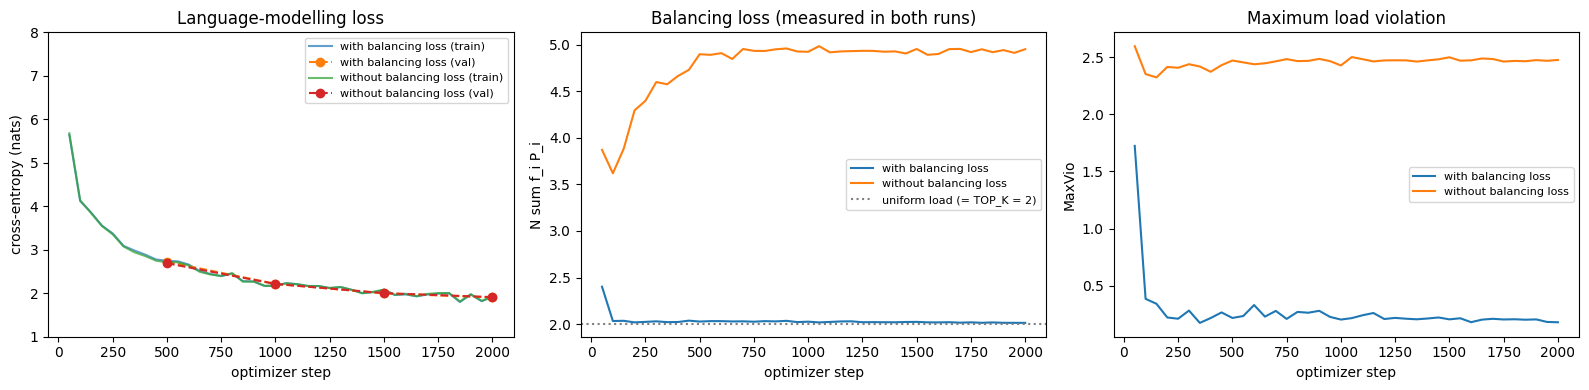

with balancing loss     : untrained 10.908 -> trained 1.913 nats (perplexity 6.8)
without balancing loss  : untrained 10.908 -> trained 1.921 nats (perplexity 6.8)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for run_name, history in histories.items():
    axes[0].plot(history["step"], history["train_loss"], alpha=0.7, label=f"{run_name} (train)")
    axes[0].plot(history["val_step"], history["val_loss"], marker="o", linestyle="--", label=f"{run_name} (val)")
    axes[1].plot(history["step"], history["balance_loss"], label=run_name)
    axes[2].plot(history["step"], history["maxvio"], label=run_name)
axes[0].set(xlabel="optimizer step", ylabel="cross-entropy (nats)", title="Language-modelling loss", ylim=(1, 8))
axes[1].axhline(TOP_K, color="grey", linestyle=":", label=f"uniform load (= TOP_K = {TOP_K})")
axes[1].set(xlabel="optimizer step", ylabel="N sum f_i P_i", title="Balancing loss (measured in both runs)")
axes[2].set(xlabel="optimizer step", ylabel="MaxVio", title="Maximum load violation")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for run_name, history in histories.items():
    print(f"{run_name:24s}: untrained {baseline_loss:.3f} -> trained {history['epoch_val_loss'][-1]:.3f} nats "
          f"(perplexity {math.exp(history['epoch_val_loss'][-1]):.1f})")

The per-layer load on the whole validation set shows where the tokens went. Each row is a layer, each column an expert, and the colour is the expert's share of the routed tokens, with the uniform share $1/N$ as the reference.

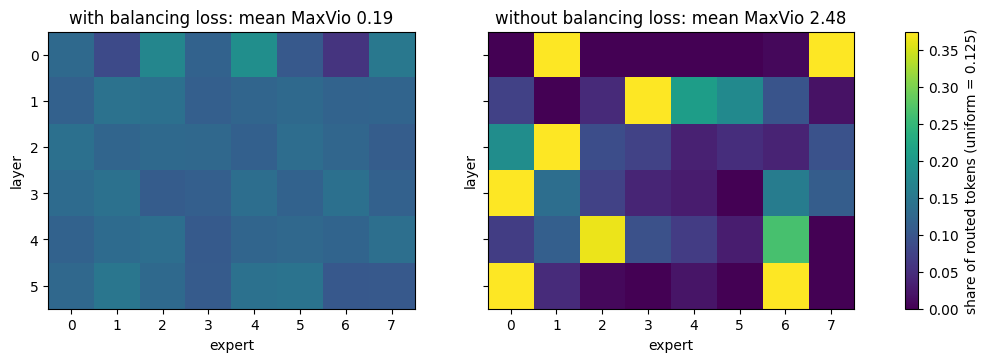

with balancing loss     : experts receiving under 1% of the tokens: 0 of 48
without balancing loss  : experts receiving under 1% of the tokens: 13 of 48


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, (run_name, history) in zip(axes, histories.items()):
    load = history["epoch_load"][-1]                                   # (N_LAYERS, N_EXPERTS)
    im = ax.imshow(load, cmap="viridis", vmin=0, vmax=min(1.0, 3 / N_EXPERTS), aspect="auto")
    ax.set(xlabel="expert", ylabel="layer", title=f"{run_name}: mean MaxVio {np.mean([max_violation(l) for l in load]):.2f}")
    ax.set_xticks(range(N_EXPERTS))
    ax.set_yticks(range(N_LAYERS))
fig.colorbar(im, ax=axes, label=f"share of routed tokens (uniform = {1 / N_EXPERTS:.3f})")
plt.show()

for run_name, history in histories.items():
    load = history["epoch_load"][-1]
    print(f"{run_name:24s}: experts receiving under 1% of the tokens: {(load < 0.01).sum().item()} of {N_LAYERS * N_EXPERTS}")

**What to notice**

Without the auxiliary loss the router drifts towards a few experts: MaxVio rises during the first few hundred steps and the heatmap shows layers in which one or two experts carry most of the tokens while others sit nearly idle, the collapse the Switch Transformer paper describes. With the loss, the balancing term sits close to its minimum of `TOP_K`, every expert carries a share near $1/N$ and MaxVio stays low. The language-modelling losses of the two runs are close at this scale, since a collapsed layer still behaves like a small dense network, but the unbalanced run wastes most of its expert parameters: idle experts never learn and would occupy serving memory for nothing. The z-loss stays small throughout, since its job is to prevent rare large logits rather than to change the routing.

## 5. Routing in a Production Mixture of Experts

The same statistics can be read off any open MoE checkpoint. [OLMoE-1B-7B](https://huggingface.co/allenai/OLMoE-1B-7B-0924) (Muennighoff et al., 2024) has 16 layers with 64 experts each and routes every token to 8 of them, so it stores 6.9B parameters and uses about 1.3B per token. Its `transformers` implementation returns the router logits of every layer with `output_router_logits=True`, exactly the tensors our `expert_load` and `max_violation` take. We route `N_OLMOE_SEQS` held-out stories through it, tokenised with its own tokenizer.

Expected time: about 3 to 5 minutes, most of it downloading 14 GB of weights.

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.37k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.12M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/287k [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

16 layers, 64 experts, 8 active per token, 6.92B parameters


routing:   0%|          | 0/8 [00:00<?, ?it/s]

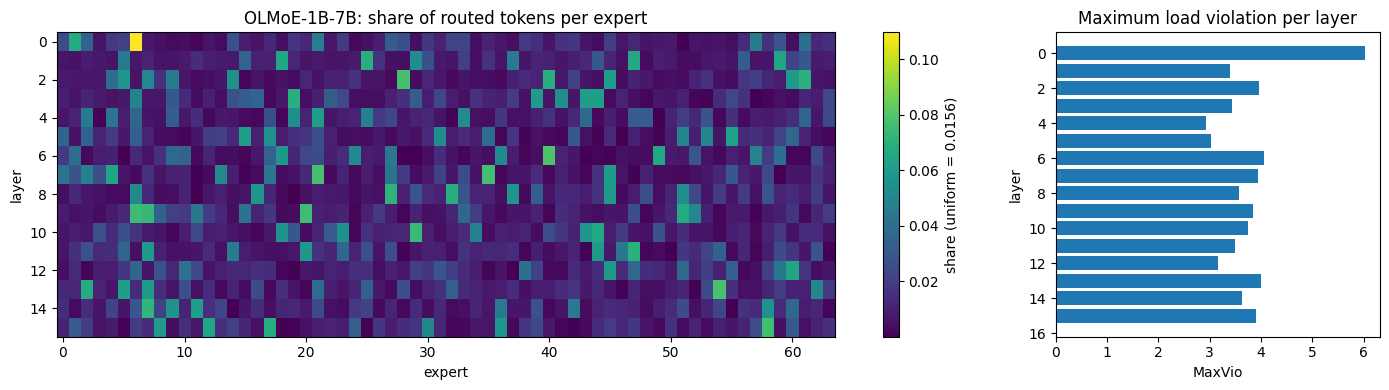

mean MaxVio over layers 3.76, experts under half the uniform share: 424 of 1024


In [13]:
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

olmoe_tokenizer = AutoTokenizer.from_pretrained(OLMOE_ID)
olmoe = AutoModelForCausalLM.from_pretrained(OLMOE_ID, dtype=torch.bfloat16).to(DEVICE).eval()
olmoe_config = olmoe.config
print(f"{olmoe_config.num_hidden_layers} layers, {olmoe_config.num_experts} experts, "
      f"{olmoe_config.num_experts_per_tok} active per token, "
      f"{sum(p.numel() for p in olmoe.parameters()) / 1e9:.2f}B parameters")

texts = [val_split[i]["text"] for i in range(N_OLMOE_SEQS)]
olmoe_ids = olmoe_tokenizer(texts, truncation=True, max_length=SEQ_LEN, padding="max_length",
                            return_tensors="pt").input_ids                                  # (N_OLMOE_SEQS, SEQ_LEN)
olmoe_load = torch.zeros(olmoe_config.num_hidden_layers, olmoe_config.num_experts)
with torch.no_grad():
    for start in tqdm(range(0, N_OLMOE_SEQS, OLMOE_BATCH_SIZE), desc="routing", leave=False):
        out = olmoe(input_ids=olmoe_ids[start:start + OLMOE_BATCH_SIZE].to(DEVICE), output_router_logits=True)
        olmoe_load += torch.stack([expert_load(l.float(), olmoe_config.num_experts_per_tok).cpu()
                                   for l in out.router_logits])
olmoe_load /= math.ceil(N_OLMOE_SEQS / OLMOE_BATCH_SIZE)

fig, (ax_map, ax_vio) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [3, 1]})
im = ax_map.imshow(olmoe_load, cmap="viridis", aspect="auto")
ax_map.set(xlabel="expert", ylabel="layer", title="OLMoE-1B-7B: share of routed tokens per expert")
fig.colorbar(im, ax=ax_map, label=f"share (uniform = {1 / olmoe_config.num_experts:.4f})")
maxvio_per_layer = [max_violation(l) for l in olmoe_load]
ax_vio.barh(range(olmoe_config.num_hidden_layers), maxvio_per_layer)
ax_vio.set(xlabel="MaxVio", ylabel="layer", title="Maximum load violation per layer")
ax_vio.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"mean MaxVio over layers {np.mean(maxvio_per_layer):.2f}, "
      f"experts under half the uniform share: {(olmoe_load < 0.5 / olmoe_config.num_experts).sum().item()} "
      f"of {olmoe_load.numel()}")

OLMoE was trained with the same Switch-style balancing loss (`router_aux_loss_coef` is 0.01 in its configuration) and a router z-loss, so its load on children's stories should be far from collapse, yet not uniform: a model trained on a broad mix of text routes a narrow domain to the experts that specialise in it.

Finally we save the weights of the balanced model and reload them into a fresh model to check that the saved file reproduces its validation loss.

In [14]:
torch.save(models["with balancing loss"].state_dict(), "moe_lm_tinystories.pth")

reloaded = build_model()
reloaded.load_state_dict(torch.load("moe_lm_tinystories.pth", map_location=DEVICE))
reloaded_loss, _ = evaluate(reloaded, val_loader)
print(f"reloaded model validation loss: {reloaded_loss:.4f} nats "
      f"(trained model: {histories['with balancing loss']['epoch_val_loss'][-1]:.4f})")

reloaded model validation loss: 1.9127 nats (trained model: 1.9127)


## Summary

- A mixture-of-experts layer stores $N$ feed-forward experts and runs only the $k$ chosen by a learned router, so parameters and per-token compute are decoupled.
- Left alone, the router concentrates tokens on a few experts, because an expert that receives more tokens learns faster and attracts more.
- The Switch Transformer balancing loss $\alpha N \sum_i f_i P_i$ is minimised by a uniform load, and the router z-loss keeps the logits small for stability.
- MaxVio summarises balance in one number and lets us compare our runs with a production model such as OLMoE.
- Dropless routing with a small balancing loss is the recipe of current open MoE models, and later work replaces the loss with a per-expert bias that only affects selection.

## Exercises

1. **Coefficient.** Train with `AUX_COEF = 1e-1` and with `AUX_COEF = 1e-3`. Compare the final MaxVio and the validation loss with the two runs above.
2. **Top-1 routing.** Set `TOP_K = 1` (the Switch Transformer) and retrain with the balancing loss. Compare the validation loss and the step time with `TOP_K = 2`.
3. **Capacity factor.** Add an `expert_capacity = int(capacity_factor * n_tokens / N_EXPERTS)` limit to `MoELayer.forward`, keep only the first `expert_capacity` tokens of each expert and let the rest pass through the residual. Train with `capacity_factor = 1.25` and report the fraction of dropped tokens with and without the balancing loss.
4. **Loss-free balancing.** Replace the balancing loss with a per-expert bias $b_i$ added to the logits only for the top-k selection, and after every step move $b_i$ up by `0.001` for experts below the mean load and down for those above, as in Wang et al. (2024). Compare MaxVio and the validation loss with the run that used the loss.

## Further Reading

- [Fedus et al., 2021. Switch Transformers: Scaling to Trillion Parameter Models with Simple and Efficient Sparsity](https://arxiv.org/abs/2101.03961)
- [Zoph et al., 2022. ST-MoE: Designing Stable and Transferable Sparse Expert Models](https://arxiv.org/abs/2202.08906)
- [Wang et al., 2024. Auxiliary-Loss-Free Load Balancing Strategy for Mixture-of-Experts](https://arxiv.org/abs/2408.15664)
- [Muennighoff et al., 2024. OLMoE: Open Mixture-of-Experts Language Models](https://arxiv.org/abs/2409.02060)
- [Sanseviero et al., 2023. Mixture of Experts Explained](https://huggingface.co/blog/moe)

### Contributed by: Mohamed Eltayeb